# Planner

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))
print(ROOT_DIR)

c:\Users\kuchbhe\Desktop\workspace_1\travelara-cd-v2


In [2]:
from __future__ import annotations
import pandas as pd
import math
from datetime import datetime, timedelta
from app.schemas import (
    PlanningRequest, POI, StructuredIntent, Itinerary, DayPlan, ItineraryStop, ItineraryScore
)
from app.graph import (
    haversine_km, cluster_pois, group_by_cluster, score_all_pois, build_knn_graph
)
from app.config import settings
from app.utils.save import save_artifact
from app.providers.provider import run_retrieval

In [3]:
from app.extractor import extract_intent
from app.schemas import StructuredIntent
import json

# request = PlanningRequest(
#     query="5-day Tokyo trip, interested in museums and food, moderate budget, staying near Shinjuku, avoid excessive walking"
# )

# intent = await extract_intent(request.query)
# save_artifact('123456', 'intent', intent)
from app.schemas import (
    StructuredIntent,
    Preferences,
    Constraints,
)

intent = StructuredIntent(
    destination="Tokyo",
    days=5,
    stay_location="Shinjuku",
    is_international=True,
    budget="medium",
    preferences=Preferences(
        museums=0.8,
        food=0.8,
        nightlife=0.0,
        nature=0.0,
        shopping=0.0,
        arts=0.0,
        history=0.0,
        wellness=0.0,
    ),
    constraints=Constraints(
        walking_limit_km=5.5,
        must_visit=[],
        avoid=[],
        budget_per_day_usd=None,
    ),
)

pois_GA, lat, lon = await run_retrieval(
    source="GA",
    intent=intent,
    debug=True
)

pois_FS, lat, lon = await run_retrieval(
    source="FS",
    intent=intent,
    debug=True
)
pois = pois_GA + pois_FS
save_artifact('123456', 'POIS', pois)


=== RETRIEVAL START ===
Provider: GA
Destination: Tokyo
Coordinates: (35.6895, 139.69171)
Preferences: {'museums': 0.8, 'food': 0.8, 'nightlife': 0.0, 'nature': 0.0, 'shopping': 0.0, 'arts': 0.0, 'history': 0.0, 'wellness': 0.0}
Processed: museums
Processed: food

=== DEDUPLICATION ===
Input POIs: 847
Output POIs: 755
Dropped: 92
By Category: {'museums': 3, 'food': 89}

=== AFTER DEDUP ===
Total POIs: 755
{'museums': 352, 'food': 403}

=== MUST VISIT FILTER ===
Must Visit Targets: []
Matched POIs: 0

=== AVOID FILTER ===
Avoid Categories: set()
Removed: 0

=== FINAL RESULT ===
Total POIs: 755
Must Visit POIs: 0
Regular POIs: 755
{'museums': 352, 'food': 403}


=== RETRIEVAL START ===
Provider: FS
Destination: Tokyo
Coordinates: (35.6895, 139.69171)
Preferences: {'museums': 0.8, 'food': 0.8, 'nightlife': 0.0, 'nature': 0.0, 'shopping': 0.0, 'arts': 0.0, 'history': 0.0, 'wellness': 0.0}
Processed: museums
Processed: food

=== DEDUPLICATION ===
Input POIs: 98
Output POIs: 49
Dropped: 49


#### Graph:

- utility score
- builds KNN using haversine
- cluster_pois uses DBSCAN
- group_by_cluster


Updates:

- pre ML filter for bad POIs
- train global algo for geospatial clustering
- use h3 indexes for better results
- benchmark the following: KNN, DBSCAN, HDBSCAN
- DS: OSM

Pre filter:

1. Filter bad names, unless in "must"/in constraint/preference
2. Whether POI in both geoapify & FS - do not automatically reject, up vote it
3. Whether POI has external links 
4. Bayesian rating & review confidence
5. Category rating

Issues:

ratings & reviews aren't reliable - can implement an enriching layer however that adds additional cost, latency & whole lot more issues. But without it, I don't have enough differentiators in the data. 

so let's say we have 11 clusters and approximate distance from centroid, I can theoretically choose the cluster with the most anchors & all. But for that I require anchors. On what basis shall those anchors be chosen on. I require an enriching layer, but the sub space is too big. Can't send it to LLM.

Filter still needed to reduce the search space - based on score & category imp, accept few, reject few

But what should be the appropriate cutoff?

Should maybe do an enriching layer, then extract some output from LLM (somehow need to bridge uncertainity - one way is to ask more questions from user) - then do a light semantic search, get top K and run through LLM for best pick?

In [ ]:
from pydantic import BaseModel, Field
from rapidfuzz import fuzz
import unicodedata
import math
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def sigmoid(x): return 1 / (1 + math.exp(-x))

class QualityScore(BaseModel):
    id: str
    name_score: float = 1.0
    source_score: float = 0.0
    tag_score: float = 0.0
    external_link_score: float = 0.0
    quality_score: float = 0.0
    overall_score: float = 0.0
    raw_score: float = 0.0
    reasons: list[str] = Field(default_factory=list)

BAD_TERMS = {"atm","parking","bus stop","toilet","restroom","taxi stand","charging station"}

TOURISM_TAG_WEIGHTS = {
    "tourism": 0.4,
    "tourism.attraction": 1.0,
    "tourism.sights": 1.0,
    "tourism.museum": 0.8,
    "building.tourism": 0.6,
    "historic": 0.8,
    "heritage": 0.8,
    "entertainment.museum": 0.8,
    "entertainment.culture": 0.6,
    "entertainment.culture.gallery": 0.5
}

def normalize_name(name: str) -> str:
    return unicodedata.normalize("NFKC", name).lower().strip()

class Filter:
    def __init__(self): pass

    @staticmethod
    def _is_same_poi(name1: str, name2: str) -> bool:
        return fuzz.token_sort_ratio(normalize_name(name1), normalize_name(name2)) >= 90

    @staticmethod
    def _score_downBT(name: str, intent) -> float:
        name_lower = name.lower()
        must_visit = {p.lower() for p in intent.constraints.must_visit}
        if any(mv in name_lower or name_lower in mv for mv in must_visit): return 1.0
        for term in BAD_TERMS:
            if term in name_lower: return 0.0
        return 1.0
    
    @staticmethod
    def _build_user_profile(intent):
        profile = []
        prefs = intent.preferences.model_dump()
        for k, v in prefs.items():
            if v > 0.3:
                profile.extend([k] * max(1, int(v * 10)))

        profile.extend(intent.constraints.must_visit)
        profile.extend(intent.constraints.avoid)

        return " ".join(profile)

    @staticmethod
    def _build_poi_profile(poi):
        return " ".join([
            poi.name,
            poi.category,
            *poi.tags
        ])

    def _score_source(self, poi, pois) -> float:
        for other in pois:
            if other.id == poi.id: continue
            if self._is_same_poi(other.name, poi.name): return 1.0
        return 0.0

    def _score_external(self, poi) -> float:
        return min(len(poi.external_links) / 3.0, 1.0)

    def _score_tags(self, poi, intent) -> float:
        score = 0.0
        prefs = {k.lower(): v for k, v in intent.preferences.model_dump().items()}
        tag_text = " ".join([poi.category, *poi.tags]).lower()
        for pref, weight in prefs.items():
            if pref in tag_text:
                score += weight
        for tag in poi.tags:
            tag_lower = tag.lower()
            for tourism_tag, tourism_weight in TOURISM_TAG_WEIGHTS.items():
                if tourism_tag in tag_lower:
                    score += tourism_weight
        return min(score, 3.0)
    
    def _semantic_scores(self, pois, intent):
        user_profile = self._build_user_profile(intent)
        poi_profiles = [self._build_poi_profile(poi) for poi in pois]

        corpus = [user_profile] + poi_profiles

        vectorizer = TfidfVectorizer(
            lowercase=True,
            stop_words="english"
        )

        X = vectorizer.fit_transform(corpus)

        user_vec = X[0]
        poi_vecs = X[1:]

        scores = cosine_similarity(
            user_vec,
            poi_vecs
        )[0]

        return {
            poi.id: float(score)
            for poi, score in zip(pois, scores)
        }

    def score_filter(self, pois, intent) -> list[QualityScore]:
        poi_scores = []
        semantic_scores = self._semantic_scores(pois, intent)
        for poi in pois:
            score_BT = self._score_downBT(poi.name, intent)
            score_source = self._score_source(poi, pois)
            score_external = self._score_external(poi)
            score_tags = self._score_tags(poi, intent)
            score_semantic = semantic_scores.get(poi.id, 0.0)

            raw_score_overall = (1.0 * score_BT) + (3.0 * score_source) + (1.5 * score_tags) + (1.0 * score_external) + (3.0 * score_semantic)
            norm_score_overall = sigmoid(raw_score_overall - 3.0)

            poi_scores.append(
                QualityScore(
                    id=poi.id,
                    name_score=score_BT,
                    source_score=score_source,
                    tag_score=score_tags,
                    external_link_score=score_external,
                    overall_score=norm_score_overall,
                    raw_score=raw_score_overall
                )
            )

            poi.append(
                POI(
                    utility_score=norm_score_overall
                )
            )

        return poi_scores

filter_obj = Filter()
poi_scores = filter_obj.score_filter(pois, intent)

In [18]:
# from pydantic import BaseModel
# from rapidfuzz import fuzz
# import unicodedata
# import math

# def sigmoid(x):
#     return 1 / (1 + math.exp(-x))

# class QualityScore(BaseModel):
#     id: str
#     name_score: float = 1.0
#     source_score: float = 0.0
#     category_score: float = 0.0
#     external_link_score: float = 0.0
#     quality_score: float = 0.0
#     overall_score: float = 0.0
#     reasons: list[str] = []
   
# BAD_TERMS = {
#     "atm",
#     "parking",
#     "bus stop",
#     "toilet",
#     "restroom",
#     "taxi stand",
#     "charging station"
# } # This wont work on multilingual data

# def normalize_name(name: str) -> str:
#     return unicodedata.normalize("NFKC", name).lower().strip()

# class Filter:
#     def __init__(self):
#         pass
    
#     @staticmethod
#     def _is_same_poi(name1: str, name2: str) -> bool:
#         n1 = normalize_name(name1)
#         n2 = normalize_name(name2)
#         score = fuzz.token_sort_ratio(n1, n2)
#         return score >= 90

#     @staticmethod
#     def _score_downBT(name: str, intent) -> float:
#         name_lower = name.lower()
#         must_visit = {p.lower() for p in intent.constraints.must_visit}
#         if any(mv in name_lower or name_lower in mv for mv in must_visit): 
#             return 1.0
#         for term in BAD_TERMS:
#             if term in name_lower:
#                 return 0.0
#         return 1.0
    
#     def _score_source(self, poi, pois):
#         for other in pois:
#             if other.id == poi.id:
#                 continue
#             if self._is_same_poi(other.name, poi.name):
#                 return 1.0
#         return 0.0
    
#     def _score_external(self, poi):
#         external_link = 0.0
#         for _ in poi.external_links:
#             external_link += 1.0
#         return external_link

#     def _score_category(self, poi, intent): # needs to be fixed - changed to semantic scoring on tags
#         category_score = 0.0

#         if poi.category in intent.preferences:
#             category_score += intent.preferences[poi.category]

#     # main class
#     def score_filter(self, pois) -> list[QualityScore]:
#         poi_scores = []
#         for poi in pois:
#             score_BT = self._score_downBT(poi.name, intent)
#             score_source = self._score_source(poi, pois)
#             score_external = self._score_external(poi)

#             raw_score_overall = (
#                     1.0 * (score_BT or 0.0)
#                     + 5.0 * (score_source or 0.0)
#                     + 1.0 * (score_external or 0.0)
#                 )
#             score_overall = sigmoid(raw_score_overall)
#             poi_scores.append(
#                 QualityScore(
#                     id = poi.id,
#                     name_score=score_BT,
#                     source_score=score_source,
#                     external_link_score=score_external,
#                     overall_score=score_overall
#                 )
#             )
#         return poi_scores

# filter_obj = Filter()
# poi_scores = filter_obj.score_filter(pois)

In [6]:
from collections import Counter

Counter(
    len(poi.external_links)
    for poi in pois
)

Counter({0: 559, 1: 222, 2: 11, 3: 7, 4: 5})

In [7]:
from collections import Counter

dist = Counter(len(poi.external_links) for poi in pois)
total = len(pois)

for links, count in sorted(dist.items()):
    print(f"{links} links: {100 * count / total:.2f}%")

0 links: 69.53%
1 links: 27.61%
2 links: 1.37%
3 links: 0.87%
4 links: 0.62%


In [14]:
high_scores = [
    score
    for score in poi_scores
    if score.overall_score >= 0.70
]

In [15]:
poi_lookup = {
    poi.id: poi
    for poi in pois
}

In [16]:
selected_pois = [
    poi_lookup[score.id]
    for score in high_scores
    if score.id in poi_lookup
]

In [17]:
selectedpois_df = pd.DataFrame(
    [poi.model_dump() for poi in selected_pois]
)

In [18]:
selectedpois_df.tags.value_counts()

tags
[entertainment, entertainment.culture, entertainment.culture.gallery]                                       79
[entertainment, entertainment.museum]                                                                       71
[building, building.tourism, entertainment, entertainment.museum]                                           29
[commercial, commercial.art, entertainment, entertainment.culture, entertainment.culture.gallery]           15
[entertainment, entertainment.museum, wheelchair, wheelchair.yes]                                           12
[building, building.public_and_civil, building.tourism, entertainment, entertainment.museum]                 8
[entertainment, entertainment.museum, fee, wheelchair, wheelchair.yes]                                       7
[entertainment, entertainment.museum, no_fee, no_fee.no]                                                     7
[building, building.tourism, entertainment, entertainment.museum, fee]                                     

Will do this:

First build the utility score for each poi -> cluster and calculate distance from each cluster -> then calculate the no. of pois nearby and the compressed score of their overall score -> select top K cluster based on this score for v1, build ML model for v2 -> then select the anchor by enriching

In [8]:
import pandas as pd


In [9]:
pois_df = pd.DataFrame(
    [poi.model_dump() for poi in pois]
)

In [10]:
pois_df[pois_df.source == 'geoapify']

,id,name,lat,lon,category,tags,popularity_score,opening_hours,external_links,rating,reviews,address,pincode,source,utility_score
0,GA_5103a3810e2976614059affc43447bd84140f00103f...,平和祈念展示資料館,35.691262,139.692512,museums,"[entertainment, entertainment.museum]",0.5,{},[],3.5,None,"Memorial Museum for Soldiers, Detainees in Sib...",160-0023,geoapify,0.0
1,GA_51938c9c853d766140593d433866d9d74140f00103f...,文化学園服飾博物館,35.686322,139.695010,museums,"[entertainment, entertainment.museum]",0.5,Tu-Su 10:00-16:30,[https://museum.bunka.ac.jp/],3.5,None,"Bunka Gakuen Costume Museum, 公衆電話, Nishi-Shinj...",160-0023,geoapify,0.0
2,GA_51b256420f4a76614059ec6dc183a6d84140f00102f...,SOMPO美術館,35.692582,139.696540,museums,"[building, building.tourism, entertainment, en...",0.5,Tu-Su 10:00-18:00,[https://sompo-museum.org],3.5,None,"Sompo Museum of Art, 1, Nishi-Shinjuku, Shinju...",160-8338,geoapify,0.0
3,GA_510de4d9e51b76614059a6153a0a6bd74140f00103f...,Hellogallerytokyo,35.682954,139.690906,museums,"[entertainment, entertainment.culture, enterta...",0.5,"4 Chome-28-7 Yoyogi, Shibuya City, Tokyo",[],3.5,None,"Hellogallerytokyo, 28-7, Yoyogi, Shibuya, Yoyo...",151-0053,geoapify,0.0
4,GA_519e0ab8e7f975614059f2086ea46cd74140f00103f...,東京オペラシティアートギャラリー,35.683003,139.686756,museums,"[entertainment, entertainment.museum]",0.5,"Su, Tu-Th 11:00-19:00; Fr-Sa 11:00-20:00",[],3.5,None,"Tokyo Opera City Art Gallery, 2, Nishi-Shinjuk...",160-0023,geoapify,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,GA_51da3a38d85b76614059e43a7c88fcd84140f00103f...,175°DENO担担麺TOKYO 新宿西口店,35.695207,139.698712,food,"[catering, catering.restaurant]",0.5,{},[],3.5,None,"175°DENO担担麺TOKYO 新宿西口店, Otakibashi-dori Avenue...",169-0073,geoapify,0.0
751,GA_51e82ff488d175614059ba2f67b62bd84140f00103f...,雪花苑,35.688834,139.681828,food,"[catering, catering.restaurant, catering.resta...",0.5,{},[],3.5,None,"雪花苑, Honan dori, Honmachi, Shibuya, Honmachi 3...",151-0071,geoapify,0.0
752,GA_513259dc7fe4756140597e1ccd9195d74140f00103f...,江戸一,35.684252,139.684143,food,"[catering, catering.fast_food, catering.fast_f...",0.5,{},[],3.5,None,"Edo-ichi, 不動通り, Honmachi, Shibuya, Honmachi 2 ...",151-0071,geoapify,0.0
753,GA_51f810f9d36b76614059d3c5014fb5d84140f00103f...,和牛処 はらぺこ亭,35.693033,139.700663,food,"[catering, catering.restaurant, catering.resta...",0.5,"Mo-Su 10:00-15:00, 17:00-22:00",[https://www.harapeko.group/],3.5,None,"Wagyu Bowl Harapekotei, 4, Shinjuku, Shinjuku,...",160-0022,geoapify,0.0


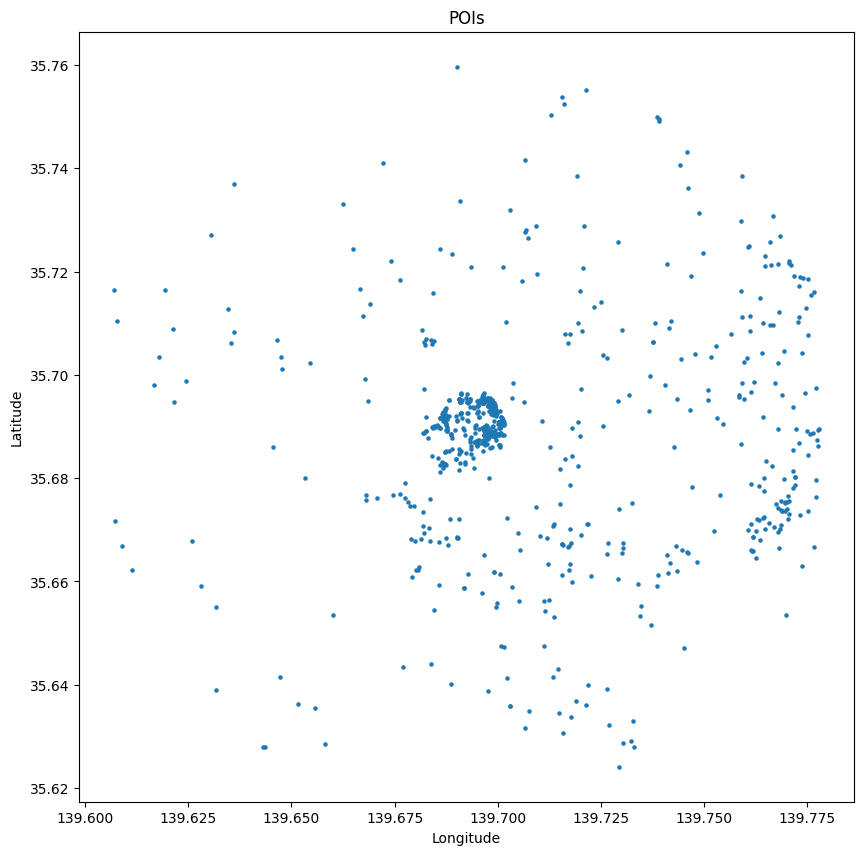

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(
    pois_df["lon"],
    pois_df["lat"],
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("POIs")
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


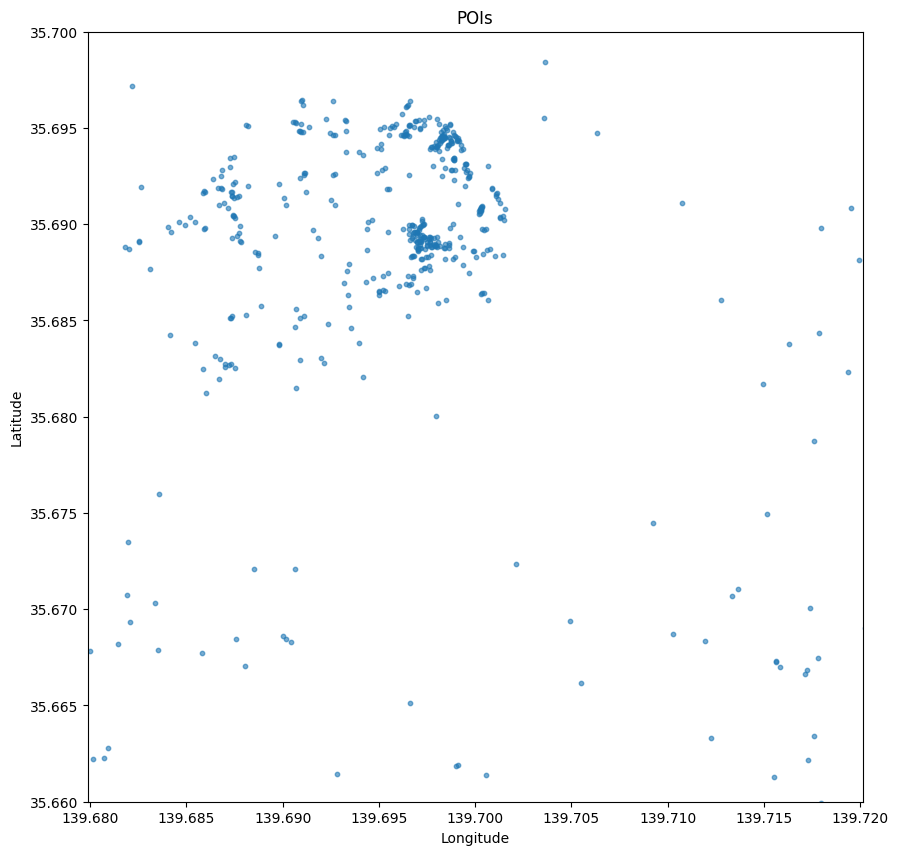

In [16]:
plt.figure(figsize=(10, 10))

plt.scatter(
    pois_df["lon"],
    pois_df["lat"],
    s=10,
    alpha=0.6
)

plt.axis("equal")
plt.xlim(
    139.68,
    139.72
)

plt.ylim(
    35.66,
    35.70
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("POIs")

plt.show()